## LOAD PACKAGES

In [2]:
!pip install ccxt

   ---------------------------------------- 0.0/6.5 MB ? eta -:--:--
   ----------------- ---------------------- 2.9/6.5 MB 13.5 MB/s eta 0:00:01
   ------------------------------ --------- 5.0/6.5 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 6.5/6.5 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 11.4 MB/s  0:00:00

   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   -------------------- ------------------- 1/2 [ccxt]
   ------

In [2]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

## CONNECTION TO KRAKEN API

In [22]:
EXCHANGE_NAME = "kraken" # change here only
exchange = getattr(ccxt, EXCHANGE_NAME)({
"enableRateLimit": True
})
exchange.load_markets()
print(f"Connected to {EXCHANGE_NAME}")
# Connected to kraken

Connected to kraken


In [157]:
symbol = "XRP/USD" # Kraken format
timeframe = "1h"
limit = 5000

ohlcv = exchange.fetch_ohlcv(
symbol=symbol,
timeframe=timeframe,
limit=limit
)

df_test = pd.DataFrame(
ohlcv,
columns=["timestamp", "open", "high", "low", "close", "volume"]
)
df_test["timestamp"] = pd.to_datetime(df_test["timestamp"], unit="ms")
df_test.tail()

,timestamp,open,high,low,close,volume
716,2026-03-08 06:00:00,1.35384,1.35498,1.35002,1.35233,64736.945267
717,2026-03-08 07:00:00,1.35225,1.36250,1.35183,1.36022,160298.424479
718,2026-03-08 08:00:00,1.36034,1.36148,1.35480,1.35921,204091.777266
719,2026-03-08 09:00:00,1.35848,1.36613,1.35604,1.36141,157883.312660
720,2026-03-08 10:00:00,1.36139,1.37075,1.36139,1.37017,77587.159250


In [158]:
df_test.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,721,2026-02-21 10:00:00,2026-02-06 10:00:00,2026-02-13 22:00:00,2026-02-21 10:00:00,2026-02-28 22:00:00,2026-03-08 10:00:00,NaN
open,721.0,1.409021,1.27785,1.36694,1.40763,1.43956,1.64965,0.049266
high,721.0,1.417401,1.28896,1.37423,1.41483,1.44816,1.67135,0.05066
low,721.0,1.400843,1.27024,1.3609,1.4,1.43167,1.61072,0.047917
close,721.0,1.409019,1.27804,1.36714,1.40766,1.43962,1.64949,0.049192
volume,721.0,907530.620144,22478.049459,322796.475018,574801.681955,1131955.146058,6477740.820638,946888.882252


In [ ]:
df_test.to_csv("prediction_date.csv")

## CONNECTION TO BITSTAMP API

In [ ]:
import ccxt
import pandas as pd
import time

exchange = ccxt.bitstamp()
symbol = 'XRP/USD'
timeframe = '15m'

# Jan 1, 2017 in milliseconds
since = exchange.parse8601('2017-01-01T00:00:00Z')
# Dec 31, 2018
end_date = exchange.parse8601('2018-12-31T23:59:59Z')

all_ohlcv = []

print("Starting data harvest...")

while since < end_date:
    try:
        # Bitstamp allows 1000 candles per pull
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
        
        if not ohlcv:
            break
            
        all_ohlcv.extend(ohlcv)
        
        # Update 'since' to the timestamp of the last candle + 15 minutes
        since = ohlcv[-1][0] + (15 * 60 * 1000)
        
        print(f"Fetched up to: {pd.to_datetime(since, unit='ms')}")
        
        # Respect Bitstamp's rate limit
        time.sleep(exchange.rateLimit / 1000)
        
    except Exception as e:
        print(f"Error: {e}")
        break

# Create the final DataFrame
df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# Verify the data
print(f"\nFinal Dataset Size: {len(df)} rows")
print(df.head())

Starting data harvest...


TypeError: '<' not supported between instances of 'int' and 'NoneType'

In [41]:
df.to_csv("xrp_15m_data_3_years.csv", index=False)

In [ ]:
# get the first 30% of df
df_30 = df.iloc[:int(len(df)*0.3)]
print(df_30.head())

df_30["timestamp"].describe() 

            timestamp   open   high    low  close  volume
0 2017-01-01 00:00:00  0.006  0.006  0.006  0.006     0.0
1 2017-01-01 00:15:00  0.006  0.006  0.006  0.006     0.0
2 2017-01-01 00:30:00  0.006  0.006  0.006  0.006     0.0
3 2017-01-01 00:45:00  0.006  0.006  0.006  0.006     0.0
4 2017-01-01 01:00:00  0.006  0.006  0.006  0.006     0.0


count                            21300
mean     2017-04-21 22:22:29.999999744
min                2017-01-01 00:00:00
25%                2017-02-25 11:11:15
50%                2017-04-21 22:22:30
75%                2017-06-16 09:33:45
max                2017-08-10 20:45:00
Name: timestamp, dtype: object

### CONNECTION TO yfinance

In [ ]:
import yfinance as yf
import pandas as pd

df = yf.download("XRP-USD", period="2y", interval="1d")

df = df.reset_index() # Moves 'Date' from index to a column
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns] # Flatten MultiIndex if necessary

prophet_df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})


# remove the last 2 months of data
df_pred = df[(df["Date"]>"2026-02-13") & (df["Date"]<"2026-03-08")]
df = df[(df["Date"]<"2026-02-13")]

print(df.describe().T)

df.to_csv("training.csv")


[*********************100%***********************]  1 of 1 completed

        count                 mean                  min                  25%  \
Date      707  2025-02-24 00:00:00  2024-03-08 00:00:00  2024-08-31 12:00:00   
Close   707.0             1.728659             0.419823             0.585329   
High    707.0             1.779705             0.433448             0.597609   
Low     707.0             1.673468             0.391139             0.570435   
Open    707.0             1.727559             0.419803             0.585332   
Volume  707.0    4598759295.496464          397026846.0         1498648842.5   

                        50%                  75%                  max  \
Date    2025-02-24 00:00:00  2025-08-19 12:00:00  2026-02-12 00:00:00   
Close              2.088549             2.404503             3.555765   
High               2.154856             2.503185              3.65021   
Low                2.028031             2.334957             3.430836   
Open               2.088495             2.404505             3.555637   
V

In [131]:
df = pd.read_csv(r"training.csv")
df_pred = pd.read_csv(r"prediction_date.csv")

print(df.describe().T)
print(df_pred.describe().T)

            count          mean           std           min           25%  \
Unnamed: 0  707.0  3.530000e+02  2.042376e+02  0.000000e+00  1.765000e+02   
Close       707.0  1.728659e+00  9.542322e-01  4.198230e-01  5.853290e-01   
High        707.0  1.779705e+00  9.833723e-01  4.334480e-01  5.976085e-01   
Low         707.0  1.673468e+00  9.247351e-01  3.911390e-01  5.704345e-01   
Open        707.0  1.727559e+00  9.549955e-01  4.198030e-01  5.853325e-01   
Volume      707.0  4.598759e+09  4.916097e+09  3.970268e+08  1.498649e+09   

                     50%           75%           max  
Unnamed: 0  3.530000e+02  5.295000e+02  7.060000e+02  
Close       2.088549e+00  2.404503e+00  3.555765e+00  
High        2.154856e+00  2.503185e+00  3.650210e+00  
Low         2.028031e+00  2.334957e+00  3.430836e+00  
Open        2.088495e+00  2.404505e+00  3.555637e+00  
Volume      3.284127e+09  5.812598e+09  5.172338e+10  
            count           mean            std           min            25

In [107]:
!pip install python-binance

  Using cached tzlocal-5.3.1-py3-none-any.whl.metadata (7.6 kB)
Using cached tzlocal-5.3.1-py3-none-any.whl (18 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 14.0 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [pycryptodome]
   ---------- ----------------------------- 1/4 [pycryptodome]
   ---------- ----------------------------- 1/4 [pycryptodome]
   ---------- ----------------------------- 1/4 [pycryptodome]
   ---------- ----------------------------- 1/4 [pycryptodome]
   ---------- ----------------------------- 1/4 [pycryptodome]
   ---------- ----------------------------- 1/4 [pycryptodome]
   -------------------- ------------------- 2/4 [dateparser]
   -------------------- ------------------- 2/4 [dateparser]
   -------------------- ------------------- 2/4 [dateparser]
   -------------------- ------------------- 2/4 [dateparser]
   -------------------- ------------------- 2/4 [datepa

## EXPLORATORY ANALYSIS AND INFERENCES

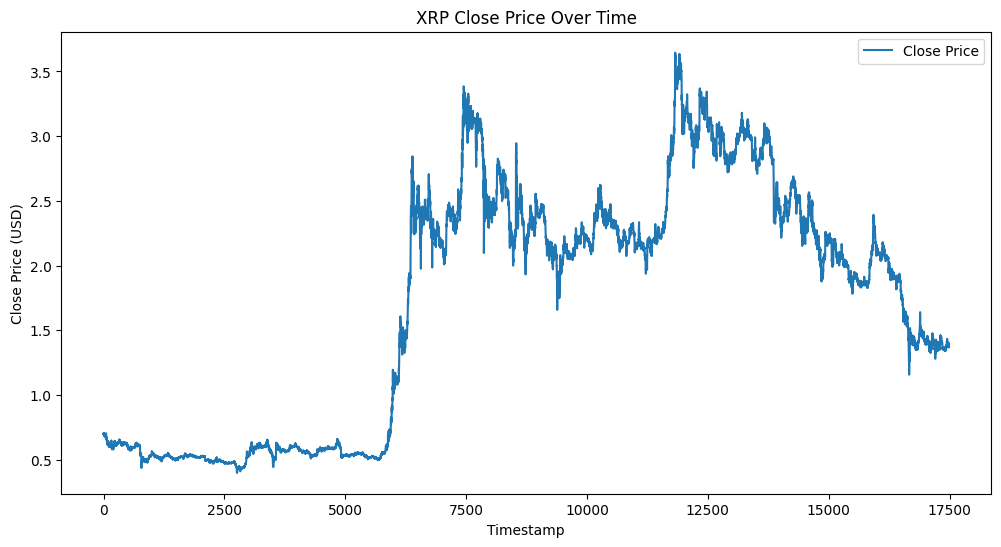

In [277]:
# plot for close price
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='Close Price')
plt.title('XRP Close Price Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 0 to 706
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  707 non-null    int64  
 1   Date        707 non-null    object 
 2   Close       707 non-null    float64
 3   High        707 non-null    float64
 4   Low         707 non-null    float64
 5   Open        707 non-null    float64
 6   Volume      707 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 38.8+ KB
None
   Unnamed: 0        Date     Close      High       Low      Open      Volume
0           0  2024-03-08  0.621955  0.634283  0.604844  0.628608  2164877115
1           1  2024-03-09  0.621805  0.633323  0.618734  0.621954  1571098762
2           2  2024-03-10  0.608432  0.628317  0.598536  0.621805  1510773123
3           3  2024-03-11  0.718036  0.742126  0.593283  0.608416  6790039283
4           4  2024-03-12  0.688209  0.730549  0.66

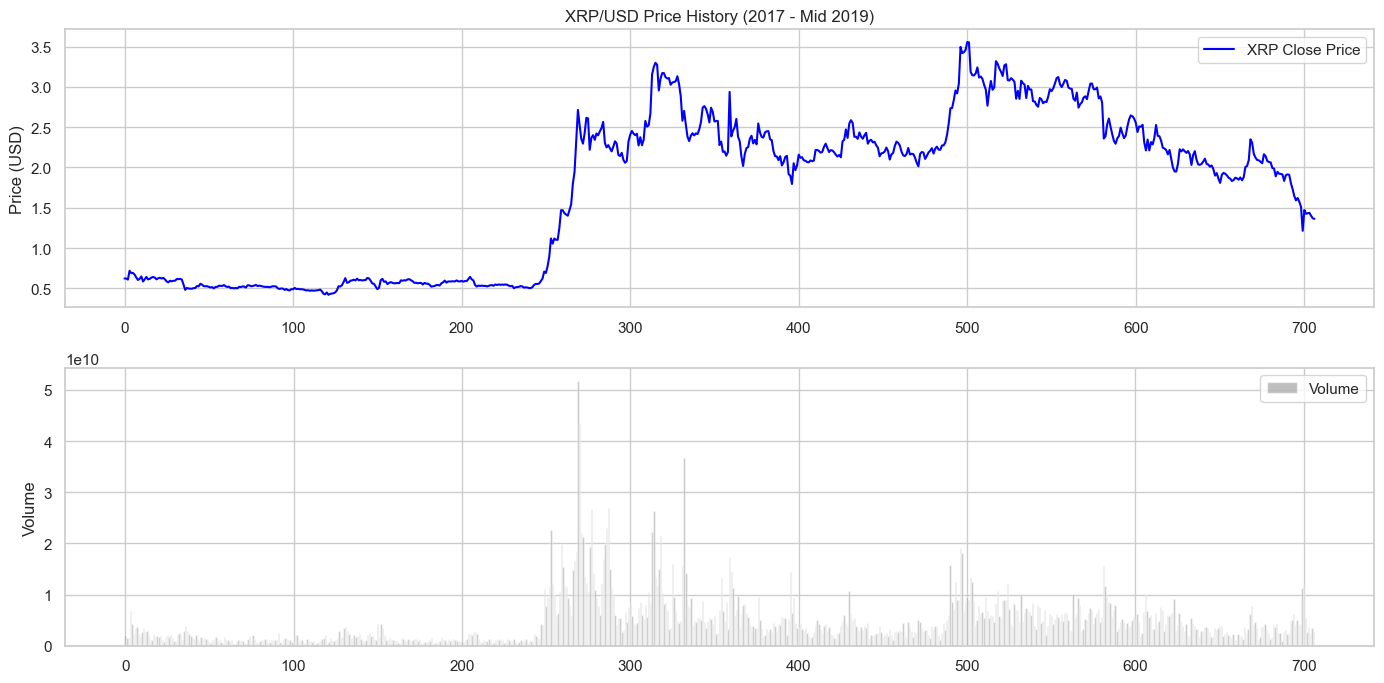

In [136]:
# Set styling
sns.set(style="whitegrid")

#df.set_index("timestamp", inplace=True)

# Inspection
print("--- Data Info ---")
print(df.info())
print(df.head())

# 2. Visualizations

# A. Price and Volume
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(df.index, df["Close"], label="XRP Close Price", color="blue")
plt.title("XRP/USD Price History (2017 - Mid 2019)")
plt.ylabel("Price (USD)")
plt.legend()

plt.subplot(2, 1, 2)
plt.bar(df.index, df["Volume"], color="gray", alpha=0.5, label="Volume")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.savefig("price_volume_history.png")
plt.show()

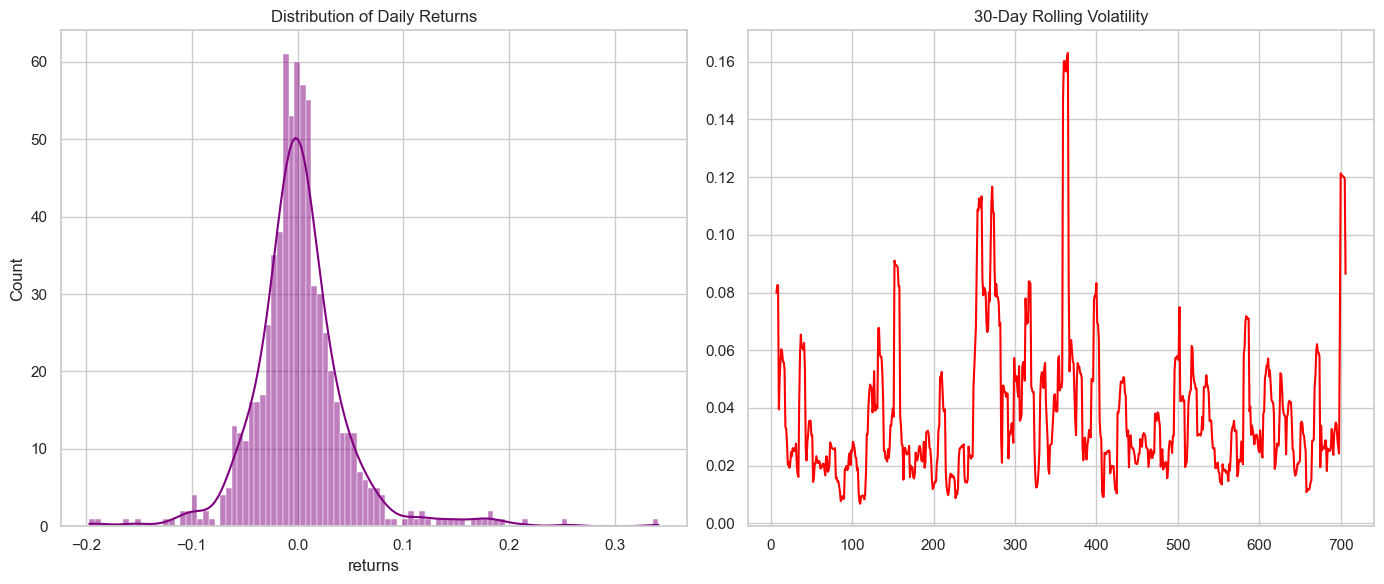

In [137]:
# B. Returns and Volatility
df["returns"] = df["Close"].pct_change()
df["rolling_vol"] = df["returns"].rolling(window=7).std()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df["returns"].dropna(), bins=100, kde=True, color="purple")
plt.title("Distribution of Daily Returns")

plt.subplot(1, 2, 2)
plt.plot(df.index, df["rolling_vol"], color="red")
plt.title("30-Day Rolling Volatility")
plt.tight_layout()
plt.show()

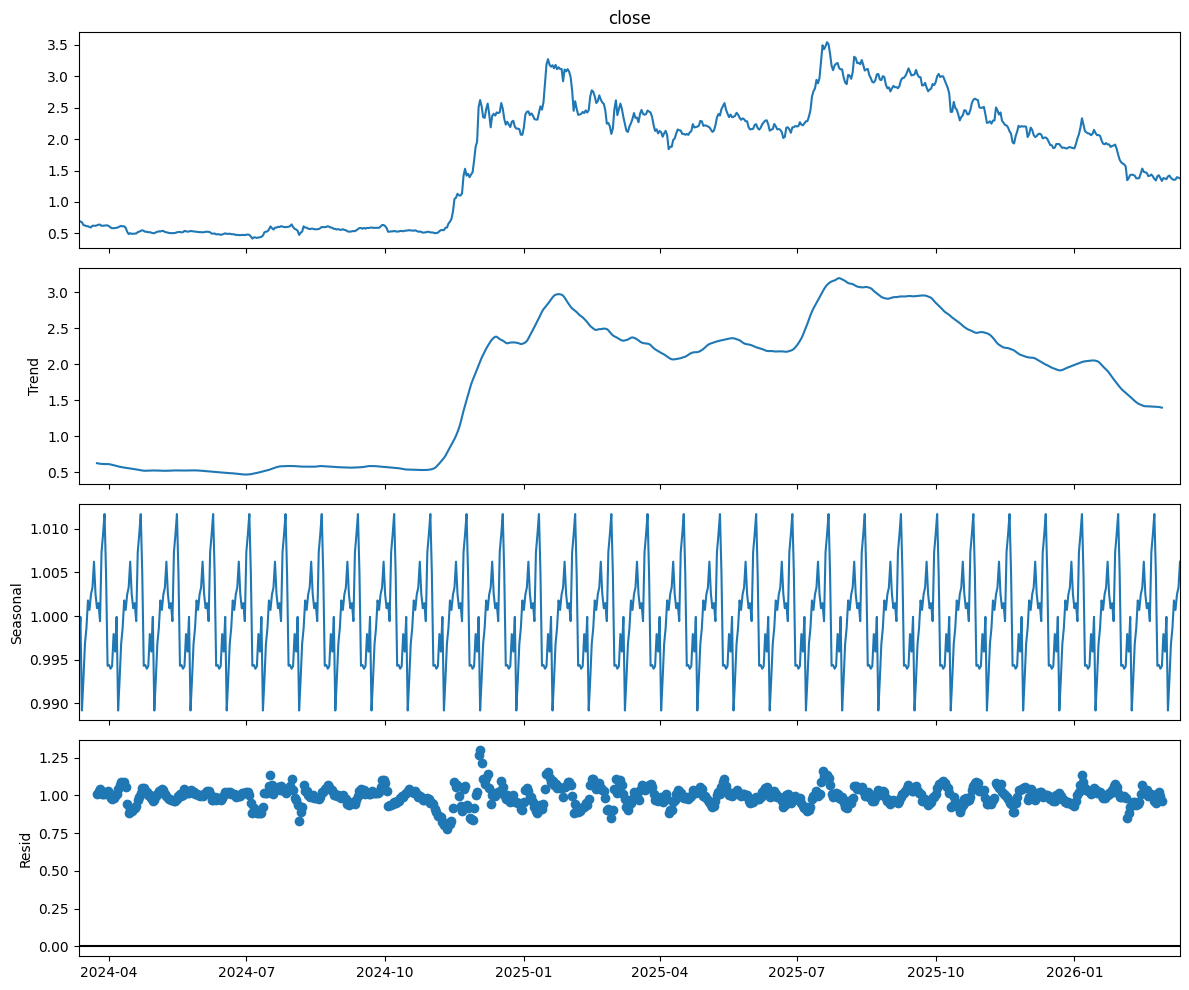

In [287]:
# C. Time Series Decomposition (using additive model)
# We handle missing values and set frequency
df['datetime'] = df.index
df['datetime'] = pd.to_datetime(df['datetime']) 

# 2. Set the index to that column
df.set_index('datetime', inplace=True)

df_decomp = df["close"].resample("D").mean().ffill()
result = seasonal_decompose(df_decomp, model='multiplicative', period=24) # Yearly periodicity

fig = result.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.savefig("time_series_decomposition.png")

In [284]:
df.index

Index(['2024-03-12 05:00:00+00:00', '2024-03-12 06:00:00+00:00',
       '2024-03-12 07:00:00+00:00', '2024-03-12 08:00:00+00:00',
       '2024-03-12 09:00:00+00:00', '2024-03-12 10:00:00+00:00',
       '2024-03-12 11:00:00+00:00', '2024-03-12 12:00:00+00:00',
       '2024-03-12 13:00:00+00:00', '2024-03-12 14:00:00+00:00',
       ...
       '2026-03-11 20:00:00+00:00', '2026-03-11 21:00:00+00:00',
       '2026-03-11 22:00:00+00:00', '2026-03-11 23:00:00+00:00',
       '2026-03-12 00:00:00+00:00', '2026-03-12 01:00:00+00:00',
       '2026-03-12 02:00:00+00:00', '2026-03-12 03:00:00+00:00',
       '2026-03-12 04:00:00+00:00', '2026-03-12 05:00:00+00:00'],
      dtype='object', name='datetime', length=17489)

In [146]:
df["Date"] = pd.to_datetime(df["Date"])

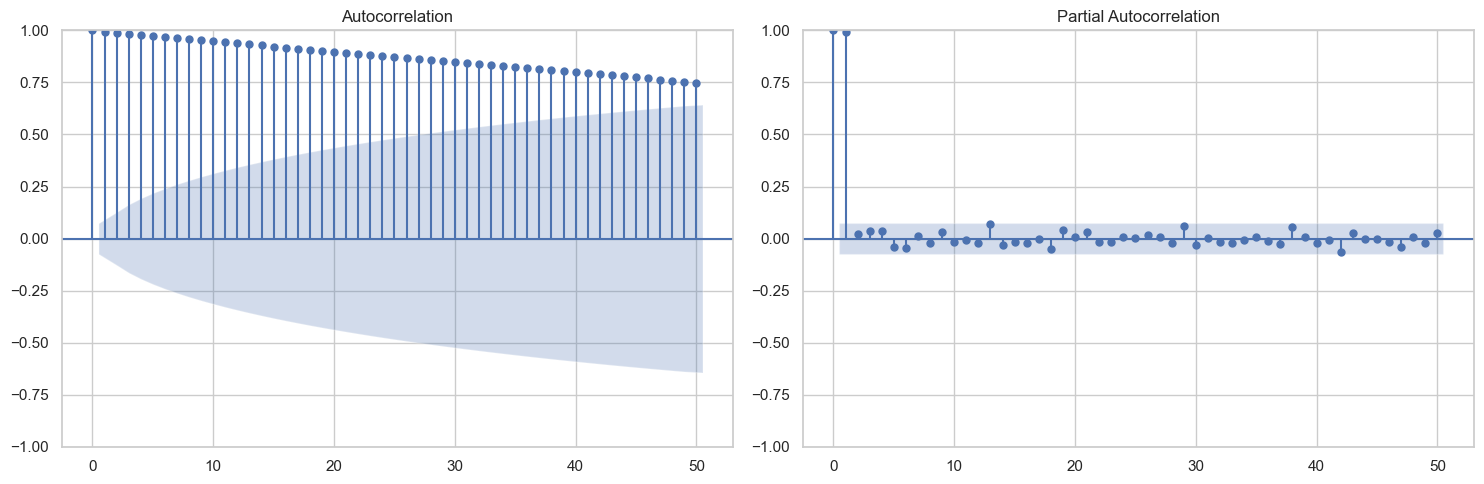

In [151]:
# D. Autocorrelation (ACF) and Partial Autocorrelation (PACF)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df["Close"], lags=50, ax=ax[0])
plot_pacf(df["Close"], lags=50, ax=ax[1])
plt.tight_layout()
plt.savefig("acf_pacf_analysis.png")

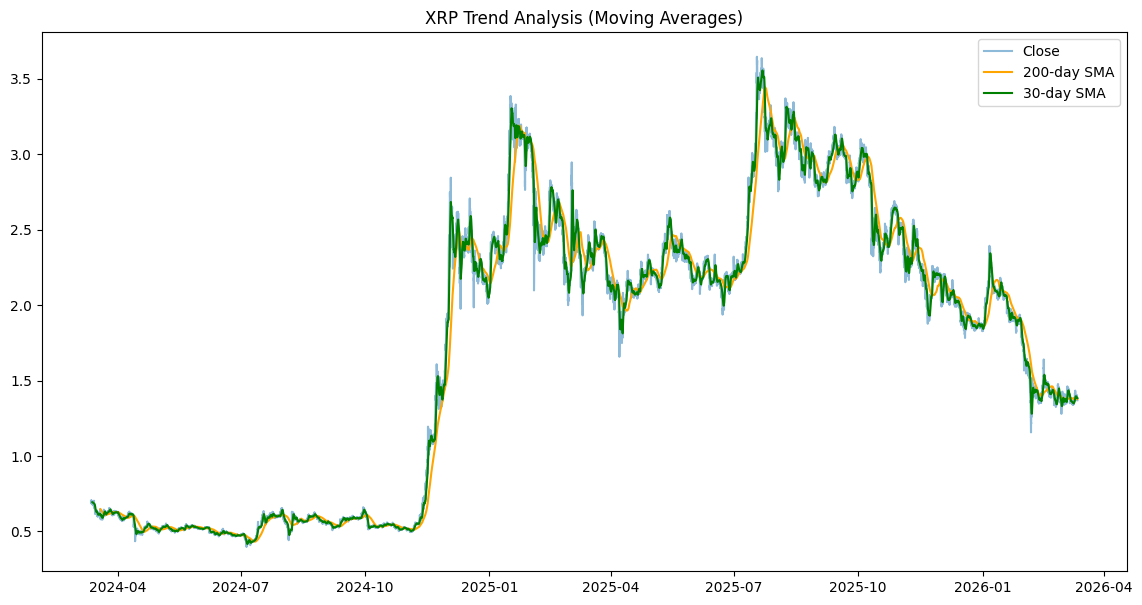

In [289]:
# E. Moving Averages
df['SMA_200'] = df['close'].rolling(window=24*7).mean()
df['SMA_30'] = df['close'].rolling(window=24).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close'], label='Close', alpha=0.5)
plt.plot(df.index, df['SMA_200'], label='200-day SMA', color='orange')
plt.plot(df.index, df['SMA_30'], label='30-day SMA', color='green')
plt.title("XRP Trend Analysis (Moving Averages)")
plt.legend()
plt.savefig("moving_averages.png")

### Key Observations
Exponential Growth: The most striking feature is the Trend line's trajectory in December. The asset moved from a value of approximately 0.2 to over 0.7 in a very short window.

Strong Seasonality: The "Seasonal" component is very regular and has a high amplitude. For a financial asset, this might reflect weekend vs. weekday trading behaviors.

Model Fit: The fact that the Residuals are not purely random suggests that the sudden spike in December was so aggressive that the standard decomposition struggled to keep up with the volatility.

## FEATURE ENGINEEIRNG AND PRE-PROCESSING

In [209]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. FEATURE ENGINEERING FUNCTION
def engineer_features(df):
    data = df.copy()
    
    # A. Momentum (RSI - 7 hour window)
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    data['rsi'] = 100 - (100 / (1 + (gain / loss)))
    
    # B. Trend (Fast vs Slow Moving Averages)
    data['sma_fast'] = data['close'].rolling(window=20).mean() # 10 hours
    data['sma_slow'] = data['close'].rolling(window=100).mean() # 50 hours
    
    # C. Volatility (24-hour rolling standard deviation)
    data['returns'] = data['close'].pct_change()
    data['volatility'] = data['returns'].rolling(window=48).std() 
    
    # D. Relative Volume (Is current volume higher than the daily average?)
    data['volume_ma'] = data['volume'].rolling(window=48).mean()
    data['rel_vol'] = data['volume'] / data['volume_ma']
    
    # E. Sessionality (Captures global trading hours)
    data['hour'] = data.index.hour
    data['is_weekend'] = data.index.dayofweek.isin([5, 6]).astype(int)
    
    # F. TARGET: Predict the return for the NEXT 30 minutes
    data['target'] = data['returns'].shift(-1)
    
    return data.dropna()

df = engineer_features(df)

KeyError: 'close'

## TRADING STRATEGY

In [296]:
# 1-day interval
df = pd.read_csv(r"Training_new_1h.csv")
print(df.index)
df.columns = df.columns.str.lower()
# load test data
# 15 min intervals
df_test = pd.read_csv(r"Testing_new_1h.csv")
df_test.columns = df_test.columns.str.lower()
print(df_test.index)

RangeIndex(start=0, stop=17489, step=1)
RangeIndex(start=0, stop=1417, step=1)


In [235]:
df.columns

Index(['datetime', 'close', 'high', 'low', 'open', 'volume'], dtype='object')

### A. TIME SERIES FORCASTING MODEL FOR DIRECTIONAL PREDICTION

#### TRAINING

12:23:22 - cmdstanpy - INFO - Chain [1] start processing
12:23:28 - cmdstanpy - INFO - Chain [1] done processing


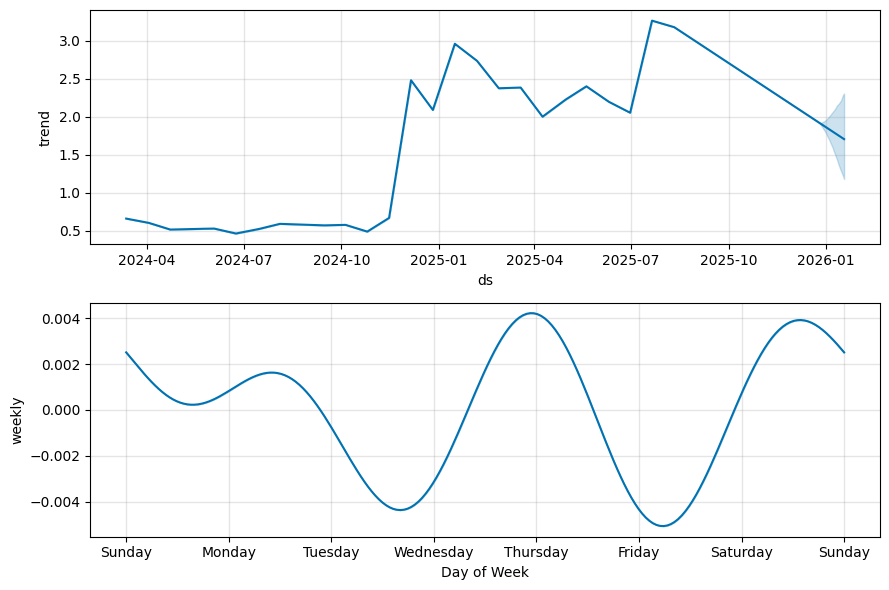

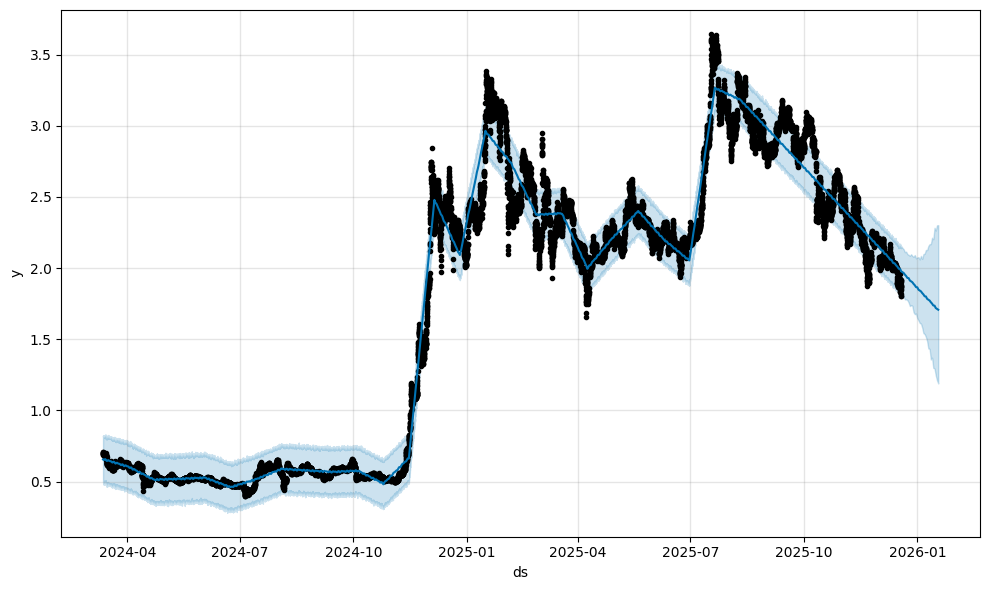

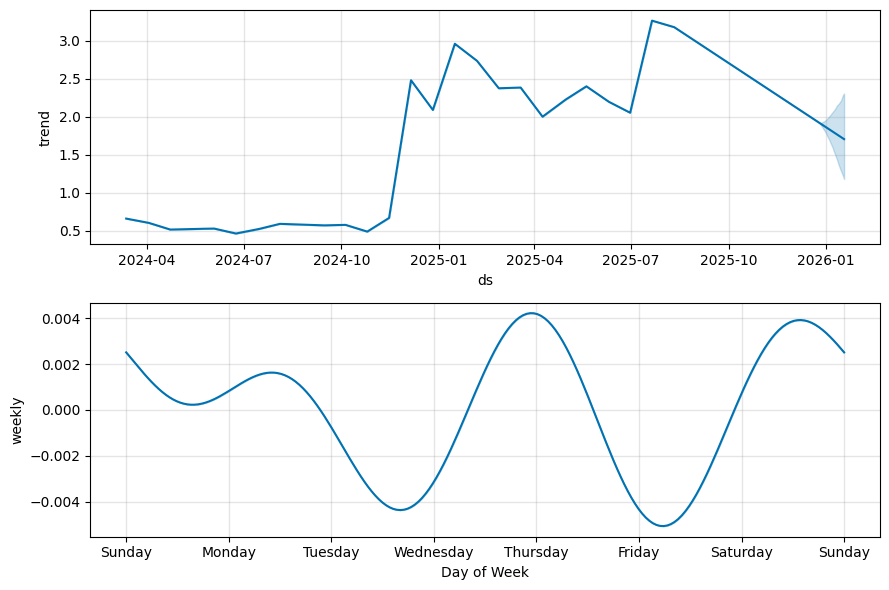

In [301]:
# facebookrophet
import pandas as pd
from prophet import Prophet

# 1. Prepare Data
prophet_df = df[['datetime', 'close']].rename(columns={'datetime': 'ds', 'close': 'y'})
# Strip the timezone from the 'ds' column
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

prophet_df = prophet_df[:-2000]

prophet_model = Prophet(
    changepoint_prior_scale=0.5, 
    weekly_seasonality=True,
    daily_seasonality=False
)

# 3. Fit and Forecast
prophet_model.fit(prophet_df)
future = prophet_model.make_future_dataframe(periods=30) # Predict 30 hours ahead
forecast = prophet_model.predict(future)

# 4. Plot
prophet_model.plot(forecast)
prophet_model.plot_components(forecast)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)
forecast['ds'] = pd.to_datetime(forecast['ds']).dt.tz_localize(None)

evaluation_df = pd.merge(prophet_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds')

# 3. Extract the columns for calculation
y_true = evaluation_df['y']
y_pred = evaluation_df['yhat']

# 4. Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"--- Prophet Model Performance ---")
print(f"MAE (Mean Absolute Error):   ${mae:.4f}")
print(f"RMSE (Root Mean Square Error): ${rmse:.4f}")
print(f"MAPE (Mean Absolute % Error):  {mape:.2f}%")
print(f"R-Squared Score:              {r2:.4f}")

--- Prophet Model Performance ---
MAE (Mean Absolute Error):   $0.0874
RMSE (Root Mean Square Error): $0.1282
MAPE (Mean Absolute % Error):  4.98%
R-Squared Score:              0.9833


#### TESTING

In [303]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Ensure both 'ds' columns are in datetime format

# 1. Prepare Data
prophet_test_df = df_test[['datetime', 'close']].rename(columns={'datetime': 'ds', 'close': 'y'})
# Strip the timezone from the 'ds' column
prophet_test_df['ds'] = pd.to_datetime(prophet_test_df['ds'])

prophet_test_df['ds'] = prophet_test_df['ds'].dt.tz_localize(None)


prophet_test_df['ds'] = pd.to_datetime(prophet_test_df['ds']).dt.tz_localize(None)

forecast_test = prophet_model.predict(prophet_test_df)

forecast_test['ds'] = pd.to_datetime(forecast_test['ds']).dt.tz_localize(None)

evaluation_test_df = pd.merge(prophet_test_df[['ds', 'y']], forecast_test[['ds', 'yhat']], on='ds')

# 3. Extract the columns for calculation
y_true_test = evaluation_test_df['y']
y_pred_test = evaluation_test_df['yhat']

# 4. Calculate Metrics
mae = mean_absolute_error(y_true_test, y_pred_test)
mse = mean_squared_error(y_true_test, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true_test - y_pred_test) / y_true)) * 100
r2 = r2_score(y_true_test, y_pred_test)

print(f"--- Prophet Model Performance ---")
print(f"MAE (Mean Absolute Error):   ${mae:.4f}")
print(f"RMSE (Root Mean Square Error): ${rmse:.4f}")
print(f"MAPE (Mean Absolute % Error):  {mape:.2f}%")
print(f"R-Squared Score:              {r2:.4f}")

--- Prophet Model Performance ---
MAE (Mean Absolute Error):   $0.1466
RMSE (Root Mean Square Error): $0.1864
MAPE (Mean Absolute % Error):  24.54%
R-Squared Score:              0.5096


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler,StandardScaler

features = ['open', 'high', 'low', 'close']
data_subset = df[features][:-1500].values

# 2. Scale all features together
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_subset)
y_scaler = StandardScaler()
y_scaler.fit(np.reshape((data_subset[:,-1]),shape=(-1,1)))


def create_windowed_data(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Look back at 15 hrs to predict the 16th
WINDOW_SIZE = 15
X, y = create_windowed_data(scaled_data, WINDOW_SIZE)

print(X.shape)
print(y.shape)

#X = np.reshape(X,shape=())

#X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 2. Build the Model
model = Sequential([
    LSTM(units=35, return_sequences=True, input_shape=(X.shape[1], 4)),
    Dropout(0.2),
    
    LSTM(units=25, return_sequences=False),
    Dropout(0.2),
    
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train
model.fit(X, y, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

# 4. Predict
predictions = model.predict(X)
predictions = y_scaler.inverse_transform(predictions)
print(f"Predicted XRP Price: {predictions[-1]}")



(15974, 15, 4)
(15974,)


c:\Users\Dhanush Ramachandran\anaconda3\envs\data_analysis_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0086 - val_loss: 6.4400e-04
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0030 - val_loss: 1.2181e-04
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0024 - val_loss: 1.4369e-04
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0020 - val_loss: 1.5987e-04
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0017 - val_loss: 7.2368e-04
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predicted XRP Price: [2.217338]


C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\2966939622.py:15: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - predictions) / y)) * 100


--- Model Evaluation for XRP ---
MAE:  0.0206 (Average error in Dollars)
RMSE: 0.0269 (Penalizes large spikes more)
R2:   0.9916 (1.0 is perfect, 0.0 is basically guessing the average)
MAPE: inf% (Average % error)


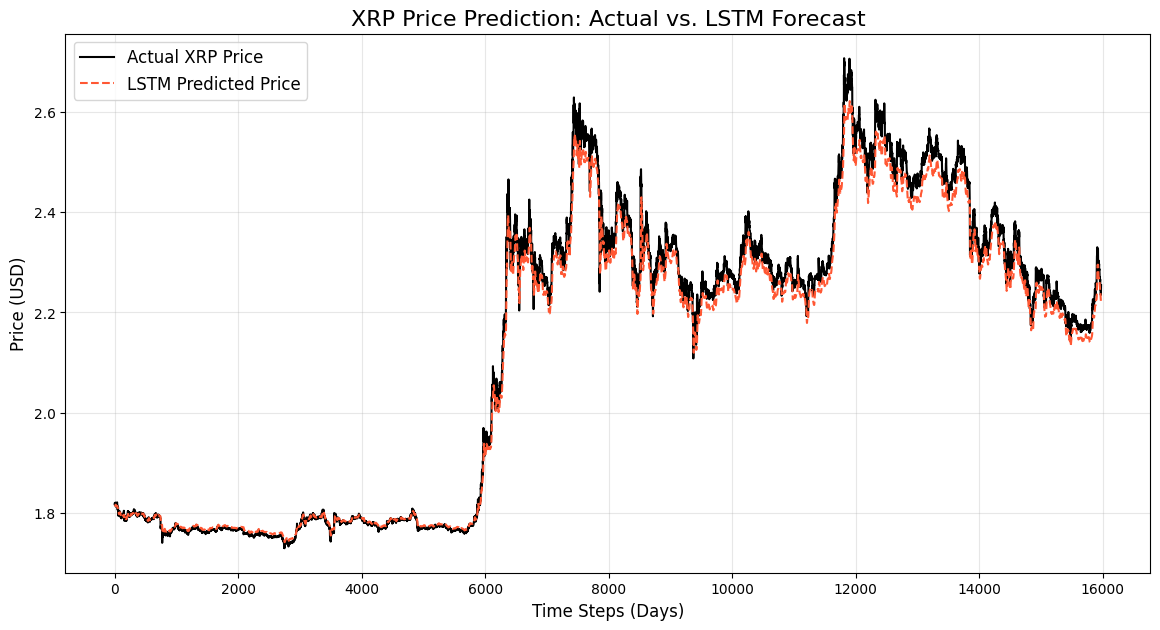

In [305]:
# training metrics
# accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
 
y_true = y_scaler.inverse_transform(np.reshape(y,shape=(-1,1)))

# 2. Calculate Metrics
mae = mean_absolute_error(y_true, predictions)
mse = mean_squared_error(y_true, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, predictions)

# 3. Calculate MAPE (Mean Absolute Percentage Error) - Very useful for Crypto
mape = np.mean(np.abs((y_true - predictions) / y)) * 100

print(f"--- Model Evaluation for XRP ---")
print(f"MAE:  {mae:.4f} (Average error in Dollars)")
print(f"RMSE: {rmse:.4f} (Penalizes large spikes more)")
print(f"R2:   {r2:.4f} (1.0 is perfect, 0.0 is basically guessing the average)")
print(f"MAPE: {mape:.2f}% (Average % error)")

# 2. Create the Plot
plt.figure(figsize=(14, 7))

# Plot Actual Values
plt.plot(y_true, label='Actual XRP Price', color='black', linewidth=1.5)

# Plot Predicted Values
plt.plot(predictions, label='LSTM Predicted Price', color='#ff5733', linestyle='--', linewidth=1.5)

# 3. Formatting
plt.title('XRP Price Prediction: Actual vs. LSTM Forecast', fontsize=16)
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)


### ON TESTING DATA

(1417, 4)
(1402, 15, 4)
(1402,)
(1402, 1)
[[2.59927979]
 [2.59414037]
 [2.57524472]
 [2.58365248]
 [2.5836618 ]]
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
pred shape:  (1402, 1)
final preds:  [[2.5455644]
 [2.5465522]
 [2.5464497]
 [2.545522 ]
 [2.544314 ]]
--- Model Evaluation for XRP ---
MAE:  0.0265 (Average error in Dollars)
RMSE: 0.0335 (Penalizes large spikes more)
R2:   0.9822 (1.0 is perfect, 0.0 is basically guessing the average)
MAPE: inf% (Average % error)


C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\4146772001.py:47: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - lstm_final_pred) / y)) * 100


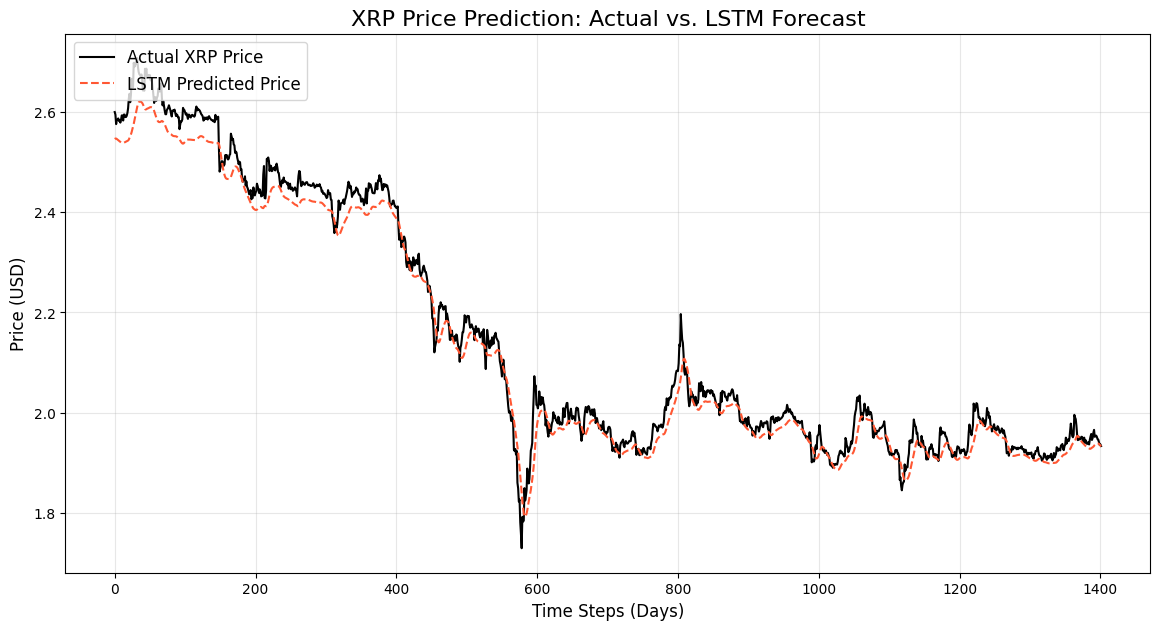

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Preprocessing
scaler = MinMaxScaler(feature_range=(0, 1))
# Reshape for the scaler
features = ['open', 'high', 'low', 'close']
scaled_data = scaler.fit_transform(df_test[features].values)

print(scaled_data.shape)

def create_windowed_data(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Look back at 15 days to predict the 16th
WINDOW_SIZE = 15
X, y = create_windowed_data(scaled_data, WINDOW_SIZE)

print(X.shape)
print(y.shape)

# 4. Predict
y_true = y_scaler.inverse_transform(np.reshape(y,(-1,1)))
y_true = np.reshape(y_true,shape=(-1,1))
print(y_true.shape)
print(y_true[:5])
lstm_scaled_pred = model.predict(X)
print("pred shape: ",lstm_scaled_pred.shape)
lstm_final_pred = y_scaler.inverse_transform(lstm_scaled_pred)
print("final preds: ",lstm_final_pred[:5])
#lstm_final_pred = scaler.inverse_transform(lstm_scaled_pred)

# 2. Calculate Metrics
mae = mean_absolute_error(y_true, lstm_final_pred)
mse = mean_squared_error(y_true, lstm_final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, lstm_final_pred)

# 3. Calculate MAPE (Mean Absolute Percentage Error) - Very useful for Crypto
mape = np.mean(np.abs((y_true - lstm_final_pred) / y)) * 100

print(f"--- Model Evaluation for XRP ---")
print(f"MAE:  {mae:.4f} (Average error in Dollars)")
print(f"RMSE: {rmse:.4f} (Penalizes large spikes more)")
print(f"R2:   {r2:.4f} (1.0 is perfect, 0.0 is basically guessing the average)")
print(f"MAPE: {mape:.2f}% (Average % error)")

# 2. Create the Plot
plt.figure(figsize=(14, 7))

# Plot Actual Values
plt.plot(y_true, label='Actual XRP Price', color='black', linewidth=1.5)

# Plot Predicted Values
plt.plot(lstm_final_pred, label='LSTM Predicted Price', color='#ff5733', linestyle='--', linewidth=1.5)

# 3. Formatting
plt.title('XRP Price Prediction: Actual vs. LSTM Forecast', fontsize=16)
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

### B. MACD BASED TECHNICAL ANALYSIS TO FINALISE THE TRADE

#### INDIVIDUAL STRATEGY OF BUY/SELL SIGNAL

In [247]:
import pandas as pd

def calculate_macd(df, fast=12, slow=26, signal=9):
    """
    Calculates MACD, Signal Line, and Histogram manually.
    """
    # 1. Calculate the Fast and Slow EMAs
    ema_fast = df['close'].ewm(span=fast, adjust=False).mean()
    ema_slow = df['close'].ewm(span=slow, adjust=False).mean()
    
    # 2. Calculate MACD Line
    df['MACD'] = ema_fast - ema_slow
    
    # 3. Calculate Signal Line (EMA of the MACD Line)
    df['MACD_Signal_Line'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    
    # 4. Calculate Histogram (Optional but useful)
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal_Line']
    
    # 5. Define Trading Signals
    df['MACD_Signal'] = 0
    # Buy signal: MACD crosses above Signal Line
    df.loc[df['MACD'] > df['MACD_Signal_Line'], 'MACD_Signal'] = 1
    # Sell signal: MACD crosses below Signal Line
    df.loc[df['MACD'] < df['MACD_Signal_Line'], 'MACD_Signal'] = -1
    
    return df

# Usage
df = calculate_macd(df_test)
print(df[['close', 'MACD', 'MACD_Signal_Line', 'MACD_Signal']].tail())


import pandas as pd

def macd_strategy(df):
    # 1. Manual MACD Calculation (as done previously)
    fast_ema = df['close'].ewm(span=12, adjust=False).mean()
    slow_ema = df['close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = fast_ema - slow_ema
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 2. Identify the Crossover Triggers
    # Logic: (Current MACD > Current Signal) AND (Previous MACD <= Previous Signal)
    df['Buy_Signal'] = (df['MACD'] > df['Signal_Line']) & (df['MACD'].shift(1) <= df['Signal_Line'].shift(1))
    
    # Logic: (Current MACD < Current Signal) AND (Previous MACD >= Previous Signal)
    df['Sell_Signal'] = (df['MACD'] < df['Signal_Line']) & (df['MACD'].shift(1) >= df['Signal_Line'].shift(1))

    # 3. Position Tracking (1 for holding, 0 for cash)
    df['Position'] = 0
    df.loc[df['Buy_Signal'], 'Position'] = 1
    df.loc[df['Sell_Signal'], 'Position'] = 0
    
    # Forward fill the position so we stay "In" the market until a sell occurs
    df['Position'] = df['Position'].replace(0, None).ffill().fillna(0)

    return df

# Apply the strategy
df = macd_strategy(df)

# View the last 10 rows where signals occurred
print(df[df['Buy_Signal'] | df['Sell_Signal']].tail(10))

         close      MACD  MACD_Signal_Line  MACD_Signal
1412  1.378165 -0.000155          0.000777           -1
1413  1.372786 -0.001272          0.000367           -1
1414  1.374001 -0.002036         -0.000113           -1
1415  1.370660 -0.002878         -0.000666           -1
1416  1.368891 -0.003645         -0.001262           -1
                       datetime     close      high       low      open  \
1314  2026-03-07 23:00:00+00:00  1.356309  1.356462  1.353759  1.353901   
1318  2026-03-08 03:00:00+00:00  1.349755  1.351127  1.346406  1.348049   
1320  2026-03-08 05:00:00+00:00  1.354248  1.355083  1.343871  1.343871   
1330  2026-03-08 15:00:00+00:00  1.345894  1.349371  1.344105  1.349371   
1335  2026-03-08 20:00:00+00:00  1.354304  1.359549  1.352959  1.355066   
1338  2026-03-08 23:00:00+00:00  1.341625  1.348871  1.341625  1.345392   
1339  2026-03-09 00:00:00+00:00  1.350205  1.355402  1.341760  1.341760   
1382  2026-03-10 19:00:00+00:00  1.382267  1.393778  1.381841  1

C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\145171924.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Position'] = df['Position'].replace(0, None).ffill().fillna(0)


#### MACD STRATEGY INCLUSIVE OF NO. OF SHARES

In [307]:
import pandas as pd
import numpy as np

def macd_share_strategy(df, initial_capital=10000):
    # 1. Manual MACD Calculation (No pandas_ta)
    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 2. Identify Crossover Triggers
    # Buy: MACD crosses ABOVE Signal | Sell: MACD crosses BELOW Signal
    df['Buy_Trigger'] = (df['MACD'] > df['Signal_Line']) & (df['MACD'].shift(1) <= df['Signal_Line'].shift(1))
    df['Sell_Trigger'] = (df['MACD'] < df['Signal_Line']) & (df['MACD'].shift(1) >= df['Signal_Line'].shift(1))

    # 3. Position Sizing Simulation
    df['Cash'] = initial_capital
    df['Shares'] = 0
    df['Portfolio_Value_MACD'] = initial_capital
    
    cash = initial_capital
    shares = 0

    for i in range(len(df)):
        price = df['close'].iloc[i]
        
        # BUY: If signal triggers and we have cash
        if df['Buy_Trigger'].iloc[i] and cash >= price:
            shares = cash // price  # Integer division for whole shares
            cash -= (shares * price)
            
        # SELL: If signal triggers and we own shares
        elif df['Sell_Trigger'].iloc[i] and shares > 0:
            cash += (shares * price)
            shares = 0
            
        # Update tracking columns
        df.at[df.index[i], 'Cash'] = cash
        df.at[df.index[i], 'Shares'] = shares
        df.at[df.index[i], 'Portfolio_Value_MACD'] = cash + (shares * price)

    return df

# Example Usage
df = macd_share_strategy(df_test, initial_capital=10000)
print(df.tail())

                       datetime     close      high       low      open  \
1412  2026-03-12 01:00:00+00:00  1.378165  1.384195  1.378165  1.384165   
1413  2026-03-12 02:00:00+00:00  1.372786  1.379927  1.372201  1.378252   
1414  2026-03-12 03:00:00+00:00  1.374001  1.375342  1.372466  1.372789   
1415  2026-03-12 04:00:00+00:00  1.370660  1.377566  1.370350  1.374034   
1416  2026-03-12 05:00:00+00:00  1.368891  1.371202  1.368842  1.370578   

        volume      MACD  Signal_Line  Buy_Trigger  Sell_Trigger  \
1412  26310912 -0.000155     0.000777        False         False   
1413  28893184 -0.001272     0.000367        False         False   
1414  16369920 -0.002036    -0.000113        False         False   
1415  13543680 -0.002878    -0.000666        False         False   
1416  14942464 -0.003645    -0.001262        False         False   

              Cash  Shares  Portfolio_Value_MACD  
1412  10053.909309       0          10053.909309  
1413  10053.909309       0          10

C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\2477522195.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.7137060165405273' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[df.index[i], 'Cash'] = cash
C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\2477522195.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10019.703325033186' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[df.index[i], 'Portfolio_Value_MACD'] = cash + (shares * price)


#### FORECASTING INDUCED MACD STRATEGY

In [308]:
def integrated_strategy(df, forecast_model, initial_capital=10000):
    # 1. Manual MACD
    print("Executing Integrated Strategy")

    ema12 = df['close'].ewm(span=9, adjust=False).mean()
    ema26 = df['close'].ewm(span=16, adjust=False).mean()
    print("EMA forecasted")
    df['MACD'] = ema12 - ema26
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 2. Setup Tracking
    cash = initial_capital
    shares = 0
    df['Portfolio_Value_MACD_F'] = initial_capital

    input_data = scaler.transform(df[["open","high","low","close"]].values)
    print(input_data.shape)

    X, y = create_windowed_data(input_data, WINDOW_SIZE)
    print(X.shape)
    pred_prices = forecast_model.predict(X)
    pred_prices = y_scaler.inverse_transform(pred_prices).reshape(-1,1)
    print(pred_prices.shape)
    zeros = np.zeros((WINDOW_SIZE, 1))
    pred_prices = np.vstack((zeros,pred_prices))
    print(pred_prices[:5])
    df["tmrw_pred_price"] = pred_prices
    print(df.columns)
    
    for i in range(WINDOW_SIZE, len(df)):
        current_price = df['close'].iloc[i]
        prev_macd = df['MACD'].iloc[i-1]
        prev_signal = df['Signal_Line'].iloc[i-1]
        curr_macd = df['MACD'].iloc[i]
        curr_signal = df['Signal_Line'].iloc[i]
        
        predicted_tomorrow = df.iloc[i]['tmrw_pred_price']
        #print(predicted_tomorrow)

        # BUY LOGIC: MACD Crossover + Positive Forecast
        is_macd_bullish = (curr_macd > curr_signal) and (prev_macd <= prev_signal)
        is_forecast_up = (predicted_tomorrow > 1.4*current_price)
        
        if is_macd_bullish and is_forecast_up and cash >= current_price:
            shares = cash // current_price
            print(shares)
            cash -= (shares * current_price)
            print(f"Day {i}: Integrated Buy at {current_price}")

        # SELL LOGIC: MACD Bearish Cross (Standard Exit)
        elif (curr_macd < curr_signal) and (prev_macd >= prev_signal) and shares > 0:
            cash += (shares * current_price)
            shares = 0
            print(f"Day {i}: Integrated Sell at {current_price}")

        df.at[df.index[i], 'Portfolio_Value_MACD_F'] = cash + (shares * current_price)

    return df

df = integrated_strategy(df= df, forecast_model = model , initial_capital=10000)
df_test.tail()


Executing Integrated Strategy
EMA forecasted
(1417, 4)
(1402, 15, 4)
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(1402, 1)
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Index(['datetime', 'close', 'high', 'low', 'open', 'volume', 'MACD',
       'Signal_Line', 'Buy_Trigger', 'Sell_Trigger', 'Cash', 'Shares',
       'Portfolio_Value_MACD', 'Portfolio_Value_MACD_F', 'tmrw_pred_price'],
      dtype='object')
8231.0
Day 595: Integrated Buy at 1.2147952318191528
Day 616: Integrated Sell at 1.4579211473464966
8743.0
Day 727: Integrated Buy at 1.3725117444992063
Day 731: Integrated Sell at 1.346438765525818
8640.0
Day 766: Integrated Buy at 1.3624885082244873
Day 788: Integrated Sell at 1.4126486778259275
9170.0
Day 1037: Integrated Buy at 1.331118106842041
Day 1057: Integrated Sell at 1.358479142189026
9188.0
Day 1122: Integrated Buy at 1.3557840585708618
Day 1129: Integrated Sell at 1.2989721298217771
8968.0
Day 1136: Integrated Buy at 1.3307713270187378
Day 1155: Integrated Sell at 1.3804042339324951
9108.0
Da

C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\2009129624.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10564.096622228624' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[df.index[i], 'Portfolio_Value_MACD_F'] = cash + (shares * current_price)


,datetime,close,high,low,open,volume,MACD,Signal_Line,Buy_Trigger,Sell_Trigger,Cash,Shares,Portfolio_Value_MACD,Portfolio_Value_MACD_F,tmrw_pred_price
1412,2026-03-12 01:00:00+00:00,1.378165,1.384195,1.378165,1.384165,26310912,-0.000685,0.000450,False,False,10053.909309,0,10053.909309,12679.945006,1.938689
1413,2026-03-12 02:00:00+00:00,1.372786,1.379927,1.372201,1.378252,28893184,-0.001732,0.000014,False,False,10053.909309,0,10053.909309,12679.945006,1.937923
1414,2026-03-12 03:00:00+00:00,1.374001,1.375342,1.372466,1.372789,16369920,-0.002330,-0.000455,False,False,10053.909309,0,10053.909309,12679.945006,1.936583
1415,2026-03-12 04:00:00+00:00,1.370660,1.377566,1.370350,1.374034,13543680,-0.002973,-0.000959,False,False,10053.909309,0,10053.909309,12679.945006,1.934838
1416,2026-03-12 05:00:00+00:00,1.368891,1.371202,1.368842,1.370578,14942464,-0.003502,-0.001467,False,False,10053.909309,0,10053.909309,12679.945006,1.932826


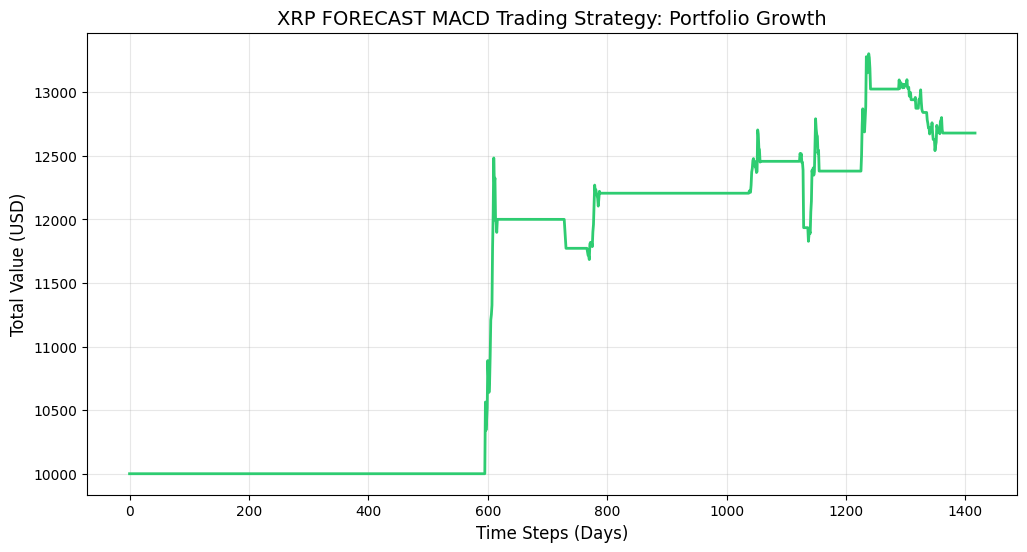

In [309]:
# PORTFOLIO DISTRIBUTION
df["Portfolio_Value_MACD_F"].describe().T
df['Portfolio_Value_MACD_F'].plot(figsize=(12, 6), color='#2ecc71', linewidth=2)

# 2. Add professional formatting
plt.title('XRP FORECAST MACD Trading Strategy: Portfolio Growth', fontsize=14)
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('Total Value (USD)', fontsize=12)
plt.grid(True, alpha=0.3)

### STRATEGY SMOOTHNESS SCORE - SHARPE

In [ ]:
## strategy smoothness analysis

import numpy as np

# 1. Calculate daily returns from your Portfolio_Value column
df_test['Daily_Return'] = df_test['Portfolio_Value'].pct_change()

# 2. Calculate the average return and the volatility (Std Dev)
avg_return = df_test['Daily_Return'].mean()
std_dev = df_test['Daily_Return'].std()

# 3. Calculate Daily Sharpe 
daily_sharpe = avg_return / std_dev

# 4. Annualize the Ratio (Crypto trades 365 days a year)
annualized_sharpe = daily_sharpe * np.sqrt(60)

print(f"Annualized Sharpe Ratio: {annualized_sharpe:.2f}")

Annualized Sharpe Ratio: 0.32


## VOLATILITY BASED STRATEGY

In [314]:
import pandas as pd
import numpy as np

def volatility_gated_strategy_hourly(df, forecast_model, scaler, initial_capital=10000):
    # Setup Parameters
    cash = initial_capital
    shares = 0

    df = df.copy()
    df['Portfolio_Value_VOL'] = initial_capital
    
    df['MA20'] = df['close'].rolling(window=20).mean()
    df['StdDev'] = df['close'].rolling(window=20).std()
    df['Upper_Band'] = df['MA20'] + (2 * df['StdDev'])
    df['Lower_Band'] = df['MA20'] - (2 * df['StdDev'])

    for i in range(20, len(df)):
        current_price = df['close'].iloc[i]
        
        last_15_hours = df[['open', 'high', 'low', 'close']].iloc[i-14:i+1].values
        
        last_15_hours_scaled = scaler.transform(last_15_hours)
        input_3d = last_15_hours_scaled.reshape(1, 15, 4)
        
        prediction_scaled = forecast_model.predict(input_3d, verbose=0)[0][0]
        
        current_scaled_close = last_15_hours_scaled[-1, 3]
        is_forecast_bullish = prediction_scaled > current_scaled_close

        if (current_price <= (df['Lower_Band'].iloc[i])) and is_forecast_bullish and cash > 0:
            shares = cash / current_price 
            cash = 0
            print(f"Hour {i}: BUY at {current_price:.4f}")

        elif (current_price >= 1.1*(df['Upper_Band'].iloc[i]) or not is_forecast_bullish) and shares > 0:
            cash = shares * current_price
            shares = 0
            print(f"Hour {i}: SELL at {current_price:.4f}")

        df.at[df.index[i], 'Portfolio_Value_VOL'] = cash + (shares * current_price)
        
    return df

#df = df_test[["open", "high", "low", "close"]]
df = volatility_gated_strategy_hourly(df, model, scaler) 


Hour 162: BUY at 1.9927


C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\4283640493.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9756.80344293202' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[df.index[i], 'Portfolio_Value_VOL'] = cash + (shares * current_price)


Hour 166: SELL at 1.9661
Hour 323: BUY at 1.8509
Hour 328: SELL at 1.8376
Hour 405: BUY at 1.8715
Hour 406: SELL at 1.8741
Hour 417: BUY at 1.8302
Hour 423: SELL at 1.8030
Hour 459: BUY at 1.6928
Hour 461: SELL at 1.7058
Hour 464: BUY at 1.6729
Hour 472: SELL at 1.6195
Hour 490: BUY at 1.5930
Hour 493: SELL at 1.6109
Hour 504: BUY at 1.5464
Hour 505: SELL at 1.5761
Hour 540: BUY at 1.5596
Hour 542: SELL at 1.5797
Hour 561: BUY at 1.5489
Hour 566: SELL at 1.5513
Hour 581: BUY at 1.3606
Hour 596: SELL at 1.2833
Hour 630: BUY at 1.3903
Hour 631: SELL at 1.4169
Hour 675: BUY at 1.4084
Hour 679: SELL at 1.4064
Hour 702: BUY at 1.4071
Hour 703: SELL at 1.4087
Hour 719: BUY at 1.3837
Hour 726: SELL at 1.3776
Hour 755: BUY at 1.3522
Hour 758: SELL at 1.3653
Hour 869: BUY at 1.4539
Hour 871: SELL at 1.4572
Hour 873: BUY at 1.4357
Hour 874: SELL at 1.4550
Hour 901: BUY at 1.4436
Hour 908: SELL at 1.4251
Hour 920: BUY at 1.3923
Hour 921: SELL at 1.4023
Hour 944: BUY at 1.3857
Hour 945: SELL at 1.

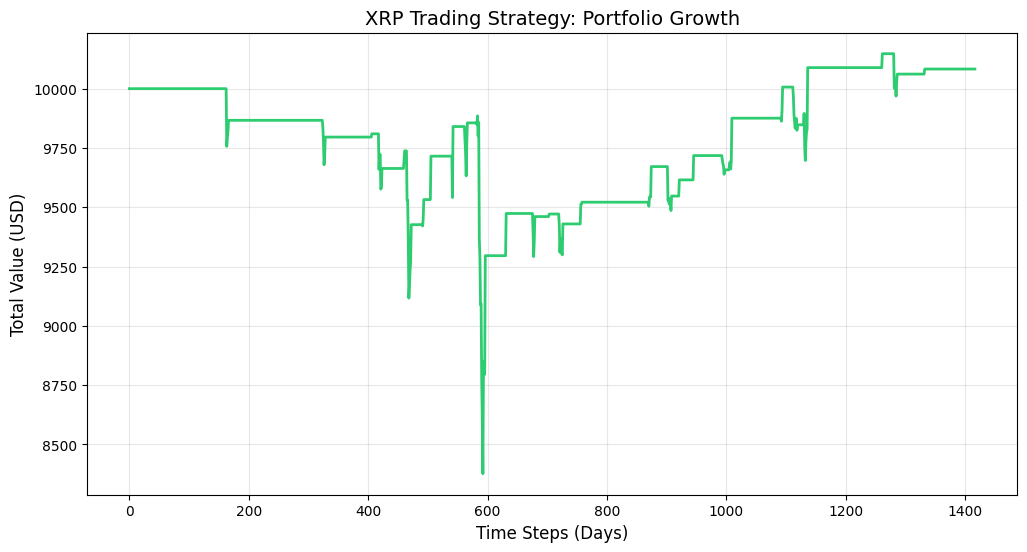

In [315]:
# BOLLINGER BAND PORTFOLIO DISTRIBUTION

df["Portfolio_Value_VOL"].describe().T
df['Portfolio_Value_VOL'].plot(figsize=(12, 6), color='#2ecc71', linewidth=2)

# 2. Add professional formatting
plt.title('XRP Trading Strategy: Portfolio Growth', fontsize=14)
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('Total Value (USD)', fontsize=12)
plt.grid(True, alpha=0.3)

## COMPARISON OF DIFF STRATEGIES ON PORTFOLIO

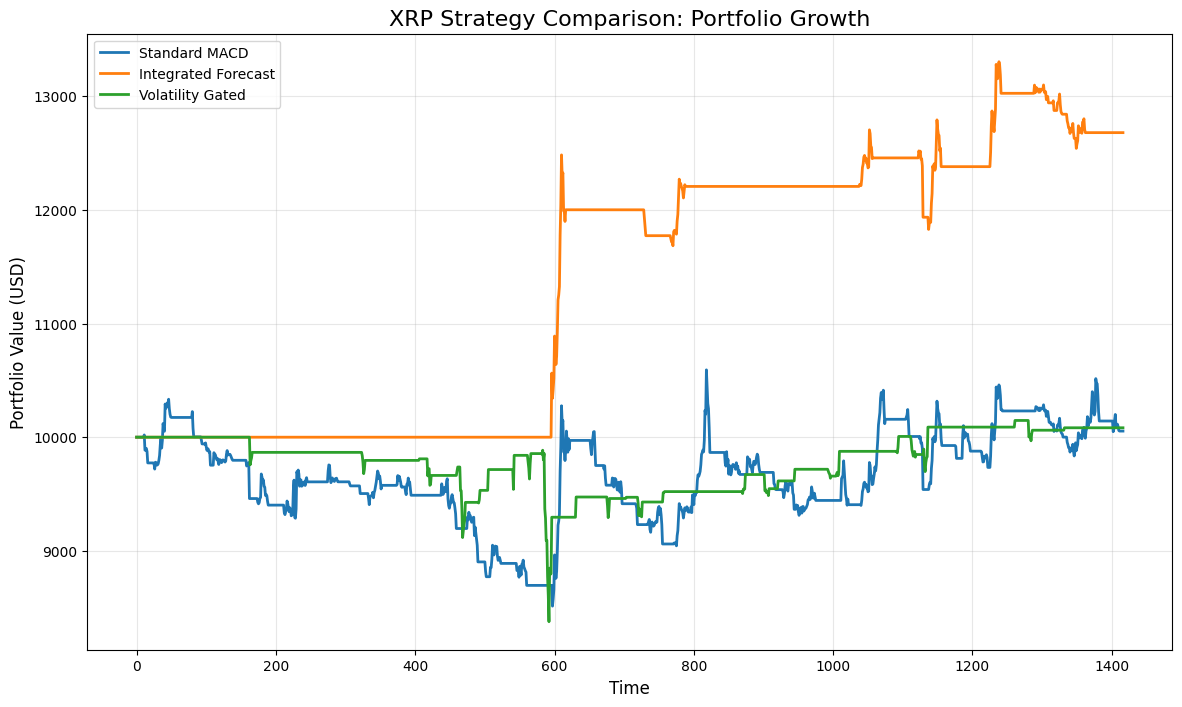


--- Strategy Performance Comparison ---
           Strategy Final Value Total Return Sharpe Ratio Max Drawdown
      Standard MACD   $10053.91        0.54%         0.32      -17.62%
Integrated Forecast   $12679.95       26.80%         4.49       -6.90%
   Volatility Gated   $10082.86        0.83%         0.32      -16.24%


C:\Users\Dhanush Ramachandran\AppData\Local\Temp\ipykernel_50736\2805750382.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(return_data, labels=[l for l in strategies.keys() if strategies[l] in df.columns])


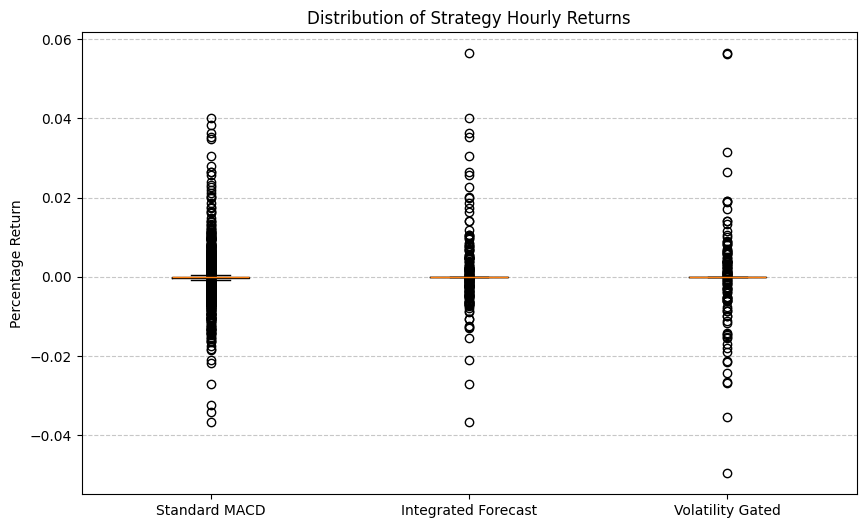

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Prepare the Comparison DataFrame
# Assuming df_test contains all three portfolio columns
strategies = {
    'Standard MACD': 'Portfolio_Value_MACD',
    'Integrated Forecast': 'Portfolio_Value_MACD_F',
    'Volatility Gated': 'Portfolio_Value_VOL'
}

plt.figure(figsize=(14, 8))

# 2. Plot Equity Curves
for label, col in strategies.items():
    if col in df.columns:
        plt.plot(df.index, df[col], label=label, linewidth=2)

plt.title('XRP Strategy Comparison: Portfolio Growth', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Portfolio Value (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('strategy_comparison_equity_curves.png')
plt.show()

# 3. Calculate Performance Metrics
results = []

for label, col in strategies.items():
    if col in df.columns:
        # Calculate Returns
        returns = df[col].pct_change().dropna()
        
        # Cumulative Return
        total_return = (df[col].iloc[-1] / df[col].iloc[0]) - 1
        
        avg_ret = returns.mean()
        std_ret = returns.std()
        sharpe = (avg_ret / std_ret) * np.sqrt(8760) if std_ret != 0 else 0
        
        # Max Drawdown
        rolling_max = df[col].cummax()
        drawdown = (df[col] - rolling_max) / rolling_max
        max_dd = drawdown.min()
        
        results.append({
            'Strategy': label,
            'Final Value': f"${df[col].iloc[-1]:.2f}",
            'Total Return': f"{total_return:.2%}",
            'Sharpe Ratio': f"{sharpe:.2f}",
            'Max Drawdown': f"{max_dd:.2%}"
        })

# 4. Display Results Table
perf_df = pd.DataFrame(results)
print("\n--- Strategy Performance Comparison ---")
print(perf_df.to_string(index=False))

# 5. Visualizing Return Distributions (Boxplot)
plt.figure(figsize=(10, 6))
return_data = [df[col].pct_change().dropna() for col in strategies.values() if col in df.columns]
plt.boxplot(return_data, labels=[l for l in strategies.keys() if strategies[l] in df.columns])
plt.title('Distribution of Strategy Hourly Returns')
plt.ylabel('Percentage Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('strategy_returns_distribution.png')
plt.show()

#### STRATEGY SMOOTHNESS ANALYSIS

In [ ]:
## strategy smoothness analysis

import numpy as np

# 1. Calculate daily returns from your Portfolio_Value column
df_test['Daily_Return'] = df_test['Portfolio_Value'].pct_change()

# 2. Calculate the average return and the volatility (Std Dev)
avg_return = df_test['Daily_Return'].mean()
std_dev = df_test['Daily_Return'].std()

# 3. Calculate Daily Sharpe (Assuming Risk-Free Rate is 0 for simplicity)
daily_sharpe = avg_return / std_dev

# 4. Annualize the Ratio (Crypto trades 365 days a year)
annualized_sharpe = daily_sharpe * np.sqrt(60)

print(f"Annualized Sharpe Ratio: {annualized_sharpe:.2f}")

Annualized Sharpe Ratio: -0.08


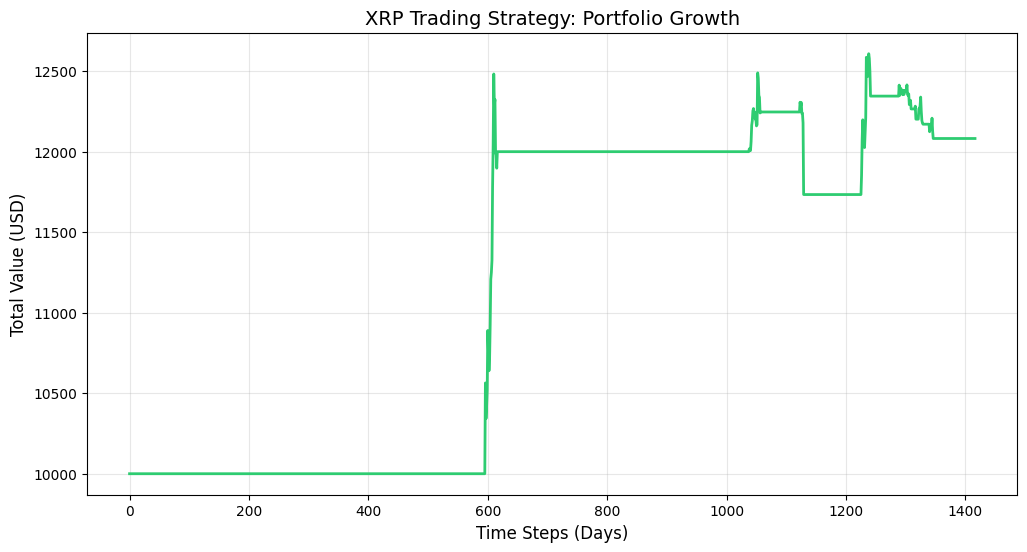

## GET TRAINING DATA - 2 years

In [ ]:
import yfinance as yf
import pandas as pd
df = yf.download(tickers="XRP-USD", period="2mo", interval="1h")

print(df.head())

df.columns = df.columns.get_level_values(0)  # Make column names lowercase for easier coding

df.columns = df.columns.str.lower()  # Make column names lowercase for easier coding
df = df.dropna()

print(df.tail())

df.describe().T
df.to_csv(r"Testing_new_1h.csv")

[*********************100%***********************]  1 of 1 completed

Price                         Close      High       Low      Open     Volume
Ticker                      XRP-USD   XRP-USD   XRP-USD   XRP-USD    XRP-USD
Datetime                                                                    
2026-01-12 05:00:00+00:00  2.080770  2.088302  2.080567  2.088302          0
2026-01-12 06:00:00+00:00  2.068669  2.081717  2.067801  2.080644   96095232
2026-01-12 07:00:00+00:00  2.054061  2.072407  2.052137  2.068581  117188608
2026-01-12 08:00:00+00:00  2.047573  2.056291  2.036144  2.053546  172271872
2026-01-12 09:00:00+00:00  2.042204  2.050364  2.042204  2.047507  111915264
Price                         close      high       low      open    volume
Datetime                                                                   
2026-03-12 01:00:00+00:00  1.378165  1.384195  1.378165  1.384165  26310912
2026-03-12 02:00:00+00:00  1.372786  1.379927  1.372201  1.378252  28893184
2026-03-12 03:00:00+00:00  1.374001  1.375342  1.372466  1.372789  16369920
2026

## GETTING TESTING DATA - 2 MONTHS

In [ ]:
import yfinance as yf
import pandas as pd
df = yf.download(tickers="XRP-USD", period="2y", interval="1h")

print(df.head())

df.columns = df.columns.get_level_values(0)  

df.columns = df.columns.str.lower()  
df = df.dropna()

print(df.tail())

df.describe().T

df.to_csv(r"Training_new_1h.csv")


[*********************100%***********************]  1 of 1 completed


Price                         Close      High       Low      Open     Volume
Ticker                      XRP-USD   XRP-USD   XRP-USD   XRP-USD    XRP-USD
Datetime                                                                    
2024-03-12 05:00:00+00:00  0.698485  0.699229  0.693571  0.696372          0
2024-03-12 06:00:00+00:00  0.696014  0.698361  0.688199  0.698361   73036800
2024-03-12 07:00:00+00:00  0.705139  0.708135  0.696009  0.696009   18230272
2024-03-12 08:00:00+00:00  0.689840  0.705255  0.683843  0.705255  125025792
2024-03-12 09:00:00+00:00  0.694894  0.697899  0.690175  0.690175   23253504
Price                         close      high       low      open    volume
Datetime                                                                   
2026-03-12 01:00:00+00:00  1.378165  1.384195  1.378165  1.384165  18325760
2026-03-12 02:00:00+00:00  1.372786  1.379927  1.372201  1.378252  14399488
2026-03-12 03:00:00+00:00  1.374001  1.375342  1.372466  1.372789   1477632
2026